<a href="https://colab.research.google.com/github/Cicero-Farias/AED/blob/main/Av_4_AED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AV4 — Estruturas de Dados

## Flocos de Neve: Busca Ingênua vs. Tabela de Dispersão

### Objetivo

Implementar duas soluções para o problema de identificação de flocos
de neve gêmeos:

1. Busca ingênua, comparando todos os pares;
2. Busca utilizando tabela de dispersão (hash).

In [15]:
import time
import itertools
import os
import matplotlib.pyplot as plt
import pandas as pd
import random

In [16]:
random.seed(3)

In [17]:
from google.colab import files

uploaded = files.upload()

Saving floco_2000_gemeo_fim.txt to floco_2000_gemeo_fim.txt
Saving floco_2000_gemeo_inicio.txt to floco_2000_gemeo_inicio.txt
Saving floco_debug_12.txt to floco_debug_12.txt
Saving floco_grande_100000.txt to floco_grande_100000.txt
Saving floco_semgemeos_500.txt to floco_semgemeos_500.txt
Saving floco_semgemeos_1000.txt to floco_semgemeos_1000.txt
Saving floco_semgemeos_2000.txt to floco_semgemeos_2000.txt
Saving floco_semgemeos_4000.txt to floco_semgemeos_4000.txt
Saving floco_semgemeos_8000.txt to floco_semgemeos_8000.txt
Saving floco_semgemeos_16000.txt to floco_semgemeos_16000.txt
Saving gerar_instancias.py to gerar_instancias.py


In [18]:
def le_instancia(caminho):
    """
    Lê um arquivo contendo uma coleção de flocos de neve.

    Formato esperado:

    N
    a1 a2 a3 a4 a5 a6
    a1 a2 a3 a4 a5 a6
    ...

    Retorna uma lista de flocos, onde cada floco é uma
    lista contendo 6 inteiros.
    """

    with open(caminho) as f:

        n = int(f.readline())

        flocos = []

        for _ in range(n):

            floco = list(map(int, f.readline().split()))

            flocos.append(floco)

    return flocos

In [19]:
def sao_gemeos(a, b):
    """
    Retorna True se o floco b for alguma rotação do floco a.

    Como cada floco possui exatamente 6 pontas, existem apenas
    6 rotações possíveis.
    """

    for deslocamento in range(6):

        rotacao = a[deslocamento:] + a[:deslocamento]

        if rotacao == b:
            return True

    return False

In [20]:
a = [2, 3, 1, 4, 5, 6]
b = [1, 4, 5, 6, 2, 3]

print(sao_gemeos(a, b))

True


In [21]:
def existe_par_gemeo_ingenuo(flocos):
    """
    Compara todos os pares possíveis de flocos.

    Retorna:
        (i, j), caso exista um par de flocos gêmeos;

        None, caso não exista nenhum par.
    """

    n = len(flocos)

    for i in range(n):

        for j in range(i + 1, n):

            if sao_gemeos(flocos[i], flocos[j]):

                return i, j

    return None

In [22]:
def chave_canonica(floco):
    """
    Retorna uma representação única para todas as rotações
    de um mesmo floco.

    A chave escolhida é a menor rotação em ordem lexicográfica.
    """

    rotacoes = []

    for deslocamento in range(6):

        rotacao = tuple(
            floco[deslocamento:] +
            floco[:deslocamento]
        )

        rotacoes.append(rotacao)

    return min(rotacoes)

In [23]:
def existe_par_gemeo_hash(flocos):
    """
    Procura um par de flocos gêmeos utilizando uma tabela hash.

    Para cada floco:
        1. Calcula sua chave canônica;
        2. Verifica se essa chave já apareceu;
        3. Se apareceu, existe um par gêmeo;
        4. Caso contrário, armazena a chave.

    Retorna:
        (i, j), se encontrar um par;

        None, caso não exista nenhum.
    """

    vistos = {}

    for j, floco in enumerate(flocos):

        chave = chave_canonica(floco)

        if chave in vistos:

            i = vistos[chave]

            return i, j

        vistos[chave] = j

    return None

In [24]:
flocos_teste = [
    [2, 3, 1, 4, 5, 6],
    [7, 7, 7, 1, 1, 1],
    [1, 4, 5, 6, 2, 3]
]

print("Ingênuo:", existe_par_gemeo_ingenuo(flocos_teste))
print("Hash:", existe_par_gemeo_hash(flocos_teste))

Ingênuo: (0, 2)
Hash: (0, 2)


In [25]:
flocos = le_instancia("floco_debug_12.txt")

resultado_ingenuo = existe_par_gemeo_ingenuo(flocos)
resultado_hash = existe_par_gemeo_hash(flocos)

print("Resultado ingênuo:", resultado_ingenuo)
print("Resultado hash:", resultado_hash)

assert (
    (resultado_ingenuo is None)
    ==
    (resultado_hash is None)
)

print("As duas soluções concordam.")

Resultado ingênuo: (2, 9)
Resultado hash: (2, 9)
As duas soluções concordam.


In [26]:
def benchmark(caminho, algoritmo, repeticoes=3):
    """
    Executa um algoritmo várias vezes e retorna o menor tempo obtido.

    Retorna:
        melhor_tempo, resultado
    """

    flocos = le_instancia(caminho)

    tempos = []

    resultado = None

    for _ in range(repeticoes):

        inicio = time.perf_counter()

        resultado = algoritmo(flocos)

        fim = time.perf_counter()

        tempos.append(fim - inicio)

    return min(tempos), resultado

In [27]:
instancias = [
    "floco_semgemeos_500.txt",
    "floco_semgemeos_1000.txt",
    "floco_semgemeos_2000.txt",
    "floco_semgemeos_4000.txt",
    "floco_semgemeos_8000.txt",
    "floco_semgemeos_16000.txt",
]

resultados = []

print(
    f"{'Instância':35s} "
    f"{'N':>8s} "
    f"{'Ingênuo (s)':>15s} "
    f"{'Hash (s)':>15s}"
)

for nome in instancias:

    flocos = le_instancia(nome)

    n = len(flocos)

    t_ingenuo, r1 = benchmark(
        nome,
        existe_par_gemeo_ingenuo
    )

    t_hash, r2 = benchmark(
        nome,
        existe_par_gemeo_hash
    )

    assert (r1 is None) == (r2 is None), \
        "As duas soluções discordam!"

    resultados.append({
        "N": n,
        "Instância": nome,
        "Ingênuo (s)": t_ingenuo,
        "Hash (s)": t_hash
    })

    print(
        f"{nome:35s} "
        f"{n:8d} "
        f"{t_ingenuo:15.6f} "
        f"{t_hash:15.6f}"
    )

Instância                                  N     Ingênuo (s)        Hash (s)
floco_semgemeos_500.txt                  500        0.213237        0.001227
floco_semgemeos_1000.txt                1000        0.857757        0.002519
floco_semgemeos_2000.txt                2000        3.482687        0.004744
floco_semgemeos_4000.txt                4000       15.281358        0.010180
floco_semgemeos_8000.txt                8000       62.847316        0.021773
floco_semgemeos_16000.txt              16000      253.703085        0.042284


Observou-se que a solução ingênua apresentou crescimento acentuado do tempo de execução para instâncias maiores. Isso ocorre porque, nas instâncias sem flocos gêmeos, o algoritmo precisa comparar praticamente todos os pares possíveis antes de concluir que não existe um par. Como o número de pares cresce quadraticamente com N, o aumento do tamanho da entrada produz um aumento muito mais rápido no tempo de execução.

In [28]:
df_resultados = pd.DataFrame(resultados)

df_resultados

,N,Instância,Ingênuo (s),Hash (s)
0,500,floco_semgemeos_500.txt,0.213237,0.001227
1,1000,floco_semgemeos_1000.txt,0.857757,0.002519
2,2000,floco_semgemeos_2000.txt,3.482687,0.004744
3,4000,floco_semgemeos_4000.txt,15.281358,0.010180
4,8000,floco_semgemeos_8000.txt,62.847316,0.021773
5,16000,floco_semgemeos_16000.txt,253.703085,0.042284


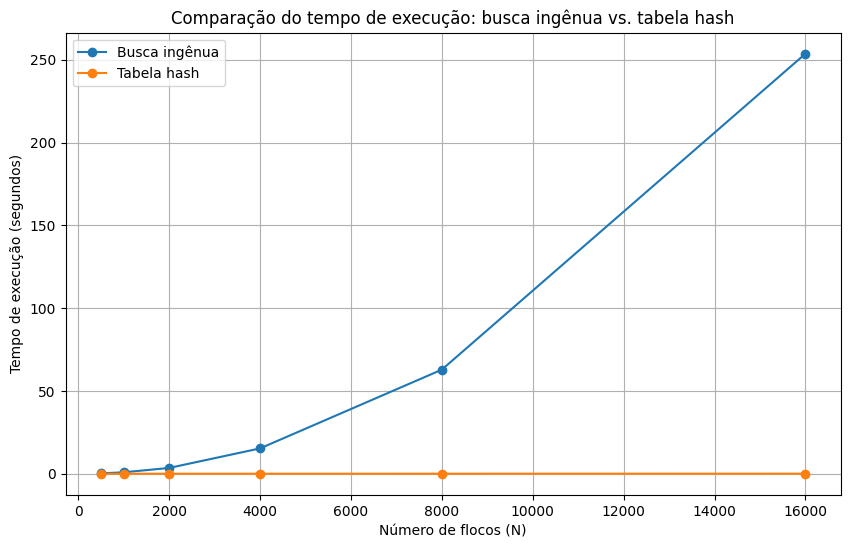

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_resultados["N"],
    df_resultados["Ingênuo (s)"],
    marker="o",
    label="Busca ingênua"
)

plt.plot(
    df_resultados["N"],
    df_resultados["Hash (s)"],
    marker="o",
    label="Tabela hash"
)

plt.xlabel("Número de flocos (N)")

plt.ylabel("Tempo de execução (segundos)")

plt.title(
    "Comparação do tempo de execução: "
    "busca ingênua vs. tabela hash"
)

plt.grid(True)

plt.legend()

plt.show()

In [30]:
instancias_gemeos = [
    "floco_2000_gemeo_inicio.txt",
    "floco_2000_gemeo_fim.txt"
]

resultados_gemeos = []

for nome in instancias_gemeos:

    flocos = le_instancia(nome)

    t_ingenuo, r1 = benchmark(
        nome,
        existe_par_gemeo_ingenuo
    )

    t_hash, r2 = benchmark(
        nome,
        existe_par_gemeo_hash
    )

    resultados_gemeos.append({
        "Instância": nome,
        "N": len(flocos),
        "Resultado ingênuo": r1,
        "Resultado hash": r2,
        "Tempo ingênuo (s)": t_ingenuo,
        "Tempo hash (s)": t_hash
    })

df_gemeos = pd.DataFrame(resultados_gemeos)

df_gemeos

,Instância,N,Resultado ingênuo,Resultado hash,Tempo ingênuo (s),Tempo hash (s)
0,floco_2000_gemeo_inicio.txt,2000,"(0, 3)","(0, 3)",0.000007,0.000012
1,floco_2000_gemeo_fim.txt,2000,"(1990, 1999)","(1990, 1999)",3.578742,0.005074


In [31]:
linha_16000 = df_resultados[
    df_resultados["N"] == 16000
].iloc[0]

tempo_16000 = linha_16000["Ingênuo (s)"]

n1 = 16000
n2 = 100000

estimativa = (
    tempo_16000 *
    (n2 / n1) ** 2
)

print(
    f"Tempo medido para N={n1}: "
    f"{tempo_16000:.6f} segundos"
)

print(
    f"Tempo estimado para N={n2}: "
    f"{estimativa:.2f} segundos"
)

print(
    f"Tempo estimado em minutos: "
    f"{estimativa / 60:.2f}"
)

Tempo medido para N=16000: 253.703085 segundos
Tempo estimado para N=100000: 9910.28 segundos
Tempo estimado em minutos: 165.17


# Análise dos resultados

## a) O que acontece quando dobramos N?

A solução ingênua possui comportamento aproximadamente quadrático,
pois compara pares de flocos. O número de comparações possíveis é:

N(N - 1) / 2.

Assim, quando N é dobrado, o número de comparações tende a aumentar
aproximadamente quatro vezes. Portanto, espera-se que o tempo de
execução da solução ingênua cresça aproximadamente por um fator de 4.

Por outro lado, a solução utilizando tabela hash percorre a coleção
uma única vez. Para cada floco é calculada uma chave canônica e é feita
uma consulta/inserção na tabela hash. Como cada floco possui sempre
6 pontas, o cálculo das rotações possui custo constante.

Dessa forma, o comportamento esperado da solução hash é aproximadamente
linear, O(N). Ao dobrar N, espera-se aproximadamente dobrar o tempo de
execução.

Os resultados experimentais confirmam essa diferença: o tempo da solução
ingênua cresce muito mais rapidamente do que o da solução com tabela hash.

## b) Gêmeo no início e gêmeo no fim

As instâncias `floco_2000_gemeo_inicio.txt` e
`floco_2000_gemeo_fim.txt` possuem o mesmo número de flocos, mas o
par gêmeo aparece em posições diferentes.

Na solução ingênua, o tempo pode variar significativamente. Como o
algoritmo compara os pares em ordem, se o par gêmeo for encontrado logo
no início, poucas comparações serão necessárias. Entretanto, se o par
estiver no final, o algoritmo poderá realizar quase todas as comparações
possíveis antes de encontrá-lo.

Assim, embora ambas as instâncias tenham N = 2000, a posição do par
gêmeo influencia o tempo de execução da solução ingênua.

Na solução com tabela hash também existe alguma diferença, pois o
algoritmo pode encerrar assim que encontra uma chave já vista. Porém,
a diferença tende a ser muito menor. Se o par estiver no início, o
algoritmo termina rapidamente; se estiver no final, percorre quase todos
os 2000 flocos. Portanto, seu comportamento permanece aproximadamente
linear em relação ao número de elementos examinados.

## c) Instância com 100.000 flocos

Não seria razoável executar diretamente a solução ingênua para a
instância com 100.000 flocos sem antes estimar seu custo.

A solução ingênua possui comportamento quadrático. Portanto, o número
de comparações cresce aproximadamente com N².

Utilizando o tempo medido para a maior instância executada, com
N = 16.000, podemos estimar:

T(100000) ≈ T(16000) × (100000 / 16000)².

O fator de crescimento é aproximadamente 39,06.

Portanto, se a execução para 16.000 flocos levar T segundos, a execução
para 100.000 flocos poderá levar aproximadamente 39,06 × T segundos,
desconsiderando variações do ambiente de execução.

Isso mostra que a abordagem ingênua se torna rapidamente inviável para
instâncias grandes. Em contraste, a solução com tabela hash apresenta
crescimento aproximadamente linear e é muito mais adequada para grandes
quantidades de flocos.